<a href="https://colab.research.google.com/github/cankurt-netizen/DSA210-PROJECT/blob/main/H2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# H2 - Saudi Arabia Weather and Date Production Analysis

## Objective

- The objective of this notebook is to analyze whether weather conditions in Saudi Arabia have an affect on date production levels over time.

## Hypothesis

- H₀: Weather variables such as temperature and precipitation do not significantly affect Saudi Arabia’s date production.

- H₁: Weather variables such as temperature and precipitation significantly affect Saudi Arabia’s date production.

## 1) Uploading Production Dataset

- Upload and load the Saudi Arabia date production dataset from FAOSTAT for further analysis.

In [ ]:
# Import libraries
import pandas as pd

# Upload production dataset
from google.colab import files
uploaded = files.upload()

# Load production dataset
df_prod = pd.read_csv("production(2).csv")

# Keep only required columns
df_prod = df_prod[["Year", "Value"]]

# Rename columns for easier analysis
df_prod.columns = ["year", "production"]

Saving production (2).csv to production (2) (1).csv


## 2) Uploading Weather Dataset

- Upload and load the historical weather dataset containing temperature and precipitation variables.

In [ ]:
# Upload weather dataset
from google.colab import files
uploaded = files.upload()

# Read weather dataset
df_weather = pd.read_csv("weather.csv", skiprows=1)

Saving weather.csv to weather.csv


## 3) Weather Data Cleaning and Preparation

- Clean the weather dataset, extract temperature and precipitation variables, and prepare yearly seasonal averages.

In [ ]:
# Load weather dataset and skip metadata rows
df_weather = pd.read_csv("weather.csv", skiprows=2)

# Find the correct weather columns automatically
date_col = [c for c in df_weather.columns if "time" in c.lower()][0]
max_col = [c for c in df_weather.columns if "temperature_2m_max" in c.lower()][0]
min_col = [c for c in df_weather.columns if "temperature_2m_min" in c.lower()][0]
rain_col = [c for c in df_weather.columns if "precipitation_sum" in c.lower()][0]

# Keep only the needed weather columns
df_weather = df_weather[[date_col, max_col, min_col, rain_col]]

# Rename columns for easier use
df_weather.columns = ["date", "temp_max", "temp_min", "precipitation"]

# Convert date column and extract year and month
df_weather["date"] = pd.to_datetime(df_weather["date"])
df_weather["year"] = df_weather["date"].dt.year
df_weather["month"] = df_weather["date"].dt.month

# Create a function to classify each month into a season
def get_season(month):
    if month in [9, 10, 11]:
        return "fall"
    elif month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    else:
        return "summer"

# Apply the season function to each row
df_weather["season"] = df_weather["month"].apply(get_season)

# Assign December to the following winter year
df_weather["season_year"] = df_weather.apply(
    lambda row: row["year"] + 1 if row["month"] == 12 else row["year"],
    axis=1
)

# Calculate average daily temperature
df_weather["temp_avg"] = (
    df_weather["temp_max"] + df_weather["temp_min"]
) / 2

# Group weather data by year and season
df_seasonal = df_weather.groupby(["season_year", "season"]).agg({
    "temp_avg": "mean",
    "precipitation": "sum"
}).reset_index()

# Rename season_year to year for merging later
df_seasonal.rename(columns={"season_year": "year"}, inplace=True)

# Convert seasonal rows into separate seasonal columns
df_weather_final = df_seasonal.pivot(index="year", columns="season")

# Clean multi-level column names
df_weather_final.columns = ["_".join(col) for col in df_weather_final.columns]

# Reset index and preview final weather dataset
df_weather_final = df_weather_final.reset_index()
df_weather_final.head()

,year,temp_avg_fall,temp_avg_spring,temp_avg_summer,temp_avg_winter,precipitation_fall,precipitation_spring,precipitation_summer,precipitation_winter
0,2000,24.389011,25.271739,33.198913,14.335833,63.9,2.7,0.0,3.5
1,2001,25.279121,25.132065,32.791304,13.405000,0.0,43.5,0.0,8.2
2,2002,25.357143,24.525543,32.938043,15.343333,3.4,58.0,0.0,26.4
3,2003,24.955495,25.354891,33.254348,14.756111,6.0,9.9,0.0,32.2
4,2004,25.271429,24.821196,33.028261,15.221429,3.9,48.2,0.0,83.9


## 4) Merging Weather and Production Data

- This part combines the production and weather datasets, then creates new weather variables for growing and harvest seasons.

In [ ]:
# Merge production data with seasonal weather data by year
df_final = pd.merge(df_prod, df_weather_final, on="year")
df_final.columns

# Create a time trend variable
df_final["year_trend"] = df_final["year"]

# Create lagged summer weather variables from the previous year
df_final["temp_summer_lag"] = df_final["temp_avg_summer"].shift(1)
df_final["rain_summer_lag"] = df_final["precipitation_summer"].shift(1)

# Drop rows with missing values caused by lagged variables
df_final = df_final.dropna()

# Create growing season temperature variable
df_final["temp_growing"] = (
    df_final["temp_avg_spring"] + df_final["temp_avg_summer"]
) / 2

# Create harvest season temperature variable
df_final["temp_harvest"] = df_final["temp_avg_fall"]

# Create growing season rainfall variable
df_final["rain_growing"] = (
    df_final["precipitation_spring"] + df_final["precipitation_summer"]
)

# Create harvest season rainfall variable
df_final["rain_harvest"] = df_final["precipitation_fall"]
df_final

,year,production,temp_avg_fall,temp_avg_spring,temp_avg_summer,temp_avg_winter,precipitation_fall,precipitation_spring,precipitation_summer,precipitation_winter,year_trend,temp_summer_lag,rain_summer_lag,temp_growing,temp_harvest,rain_growing,rain_harvest
1,2000,5158.60,24.389011,25.271739,33.198913,14.335833,63.9,2.7,0.0,3.5,2000,33.198913,0.0,29.235326,24.389011,2.7,63.9
2,2000,734844.00,24.389011,25.271739,33.198913,14.335833,63.9,2.7,0.0,3.5,2000,33.198913,0.0,29.235326,24.389011,2.7,63.9
3,2001,139099.00,25.279121,25.132065,32.791304,13.405000,0.0,43.5,0.0,8.2,2001,33.198913,0.0,28.961685,25.279121,43.5,0.0
4,2001,5879.90,25.279121,25.132065,32.791304,13.405000,0.0,43.5,0.0,8.2,2001,32.791304,0.0,28.961685,25.279121,43.5,0.0
5,2001,817887.00,25.279121,25.132065,32.791304,13.405000,0.0,43.5,0.0,8.2,2001,32.791304,0.0,28.961685,25.279121,43.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2023,8128.60,27.396154,24.388587,34.555978,15.017778,20.2,67.8,0.0,124.2,2023,34.555978,0.0,29.472283,27.396154,67.8,20.2
71,2023,1903102.00,27.396154,24.388587,34.555978,15.017778,20.2,67.8,0.0,124.2,2023,34.555978,0.0,29.472283,27.396154,67.8,20.2
72,2024,257613.00,27.186813,24.785326,35.208152,16.720879,5.2,84.5,0.0,21.0,2024,34.555978,0.0,29.996739,27.186813,84.5,5.2
73,2024,7482.40,27.186813,24.785326,35.208152,16.720879,5.2,84.5,0.0,21.0,2024,35.208152,0.0,29.996739,27.186813,84.5,5.2


## 5) Linear Regression Model

- Apply an Ordinary Least Squares (OLS) regression model to examine the relationship between weather conditions and date production.

In [ ]:
import statsmodels.api as sm
import numpy as np

# Apply log transformation to production
df_final["log_production"] = np.log(df_final["production"])

# Select explanatory variables
X = df_final[["temp_avg_summer", "precipitation_fall", "year_trend"]]

# Define target variable
y = df_final["log_production"]

# Add constant term
X = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         log_production   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.035
Method:                 Least Squares   F-statistic:                    0.1676
Date:                Tue, 14 Apr 2026   Prob (F-statistic):              0.918
Time:                        14:52:50   Log-Likelihood:                -158.83
No. Observations:                  74   AIC:                             325.7
Df Residuals:                      70   BIC:                             334.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                -29.1986    108

## Results

- The regression model tested whether summer temperature, fall precipitation, and yearly trend have an effect on Saudi Arabia’s date production.

- The model produced a very low R² value of 0.007, showing that the weather variables explain very little of the variation in production.

- The p-values for temp_avg_summer (0.940), precipitation_fall (0.899), and year_trend (0.750) were all greater than 0.05.

- Since all p-values are above 0.05, we fail to reject the null hypothesis (H₀).

- This indicates that the selected weather variables do not have a statistically significant relationship with Saudi Arabia’s date production in this regression model.

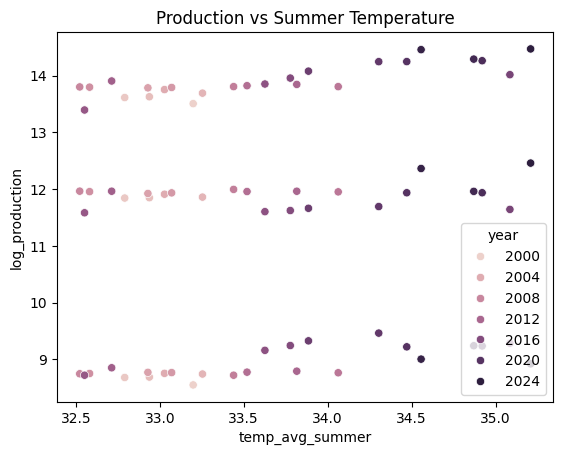

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create scatter plot between summer temperature and production
sns.scatterplot(x="temp_avg_summer", y="log_production", hue="year", data=df_final)

# Add title to the graph
plt.title("Production vs Summer Temperature")

# Display graph
plt.show()

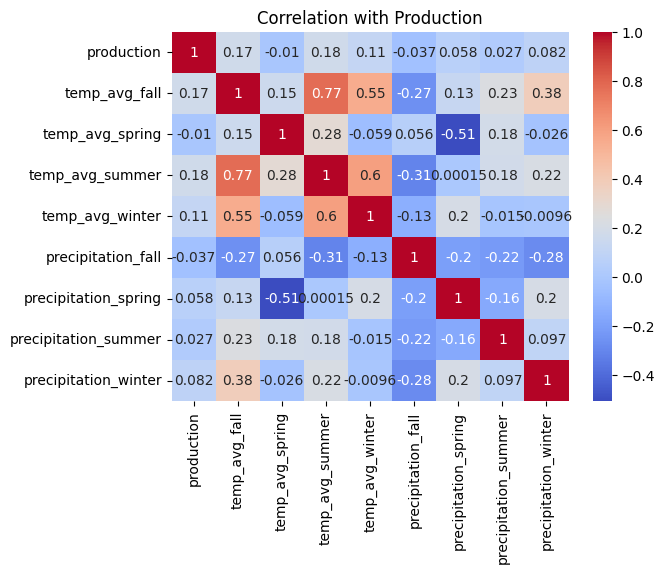

In [ ]:
cols = [
    "production",
    "temp_avg_fall",
    "temp_avg_spring",
    "temp_avg_summer",
    "temp_avg_winter",
    "precipitation_fall",
    "precipitation_spring",
    "precipitation_summer",
    "precipitation_winter"
]

# Create correlation heatmap between production and weather variables
sns.heatmap(df_final[cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation with Production")
plt.show()